# **Big Data Analysis Project**
## Group 2 - CitiBike Trips
### Group Members:
1. La Tania Nur Tenka (23/511504/PA/21787)
2. Rr. Garzetta Aleyda H. (23/511422/PA/21793)
3. Benedicta Edita P. (23/511537/PA/21815)

### Questions:
1. What are the peak riding hours per day?
2. ⁠Which stations has the highest trip starts?
3. ⁠What is the average trip duration by user type (member vs casual)?
4. ⁠What is the difference in demand for weekdays and weekends?
5. ⁠What is the average trip duration by hour?

## **Environment Setup**

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql.window import *
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
spark = SparkSession.builder.appName('CitiBikeTrip_Project').getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/11 17:31:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## **Data Ingestion**

### Load Data

In [3]:
# Explicit Schema
schema = StructType([
    StructField("ride_id", StringType(), True),
    StructField("rideable_type", StringType(), True),
    StructField("started_at", StringType(), True),
    StructField("ended_at", StringType(), True),
    StructField("start_station_name", StringType(), True),
    StructField("start_station_id", StringType(), True),
    StructField("end_station_name", StringType(), True),
    StructField("end_station_id", StringType(), True),
    StructField("start_lat", DoubleType(), True),
    StructField("start_lng", DoubleType(), True),
    StructField("end_lat", DoubleType(), True),
    StructField("end_lng", DoubleType(), True),
    StructField("member_casual", StringType(), True),
    StructField("_corrupt_record", StringType(), True)
])

df = spark.read.csv(
    path='/Users/benedictaedita/Desktop/Codes/BDA Project PySpark/202509-citibike-tripdata.csv', 
    header=True, 
    schema=schema,
    mode="PERMISSIVE",
    columnNameOfCorruptRecord="_corrupt_record"
)

### Handling Corrupt Rows

In [4]:
df.filter(col("_corrupt_record").isNotNull()).show()

+-------+-------------+----------+--------+------------------+----------------+----------------+--------------+---------+---------+-------+-------+-------------+---------------+
|ride_id|rideable_type|started_at|ended_at|start_station_name|start_station_id|end_station_name|end_station_id|start_lat|start_lng|end_lat|end_lng|member_casual|_corrupt_record|
+-------+-------------+----------+--------+------------------+----------------+----------------+--------------+---------+---------+-------+-------+-------------+---------------+
+-------+-------------+----------+--------+------------------+----------------+----------------+--------------+---------+---------+-------+-------+-------------+---------------+



There is no corrupt rows, drop the column

In [5]:
df = df.drop((col("_corrupt_record")))
df.show()

+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+------------------+------------------+-------------+
|         ride_id|rideable_type|          started_at|            ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|        start_lat|         start_lng|           end_lat|           end_lng|member_casual|
+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+------------------+------------------+-------------+
|3B0C318A532F94B6|electric_bike|2025-09-03 12:44:...|2025-09-03 12:59:...|     W 13 St & 5 Ave|         5947.04|     E 54 St & 1 Ave|       6608.09|        40.735445|         -73.99431|         40.756265|        -73.964179|       member|
|67CC23751CDE251A| classic_bike|2025-09-14 09:18

### Dataset Size Report

In [6]:
print("Rows:", df.count())
print("Columns:", len(df.columns))
df.printSchema()

Rows: 5287447
Columns: 13
root
 |-- ride_id: string (nullable = true)
 |-- rideable_type: string (nullable = true)
 |-- started_at: string (nullable = true)
 |-- ended_at: string (nullable = true)
 |-- start_station_name: string (nullable = true)
 |-- start_station_id: string (nullable = true)
 |-- end_station_name: string (nullable = true)
 |-- end_station_id: string (nullable = true)
 |-- start_lat: double (nullable = true)
 |-- start_lng: double (nullable = true)
 |-- end_lat: double (nullable = true)
 |-- end_lng: double (nullable = true)
 |-- member_casual: string (nullable = true)



## **Data Cleaning**

### Type Conversion

In [7]:
# string → timestamp
df = df.withColumn("started_at", to_timestamp("started_at", "yyyy-MM-dd HH:mm:ss.SSS"))\
    .withColumn("ended_at", to_timestamp("ended_at", "yyyy-MM-dd HH:mm:ss.SSS")
)

Spark CSV reader does not automatically parse custom timestamp formats safely.  
The dataset has timestamp like: `2025-09-03 12:44:03.601`  
If timestamp type is defined in the explicit schema, Spark will try to parse it automatically.

Problems that can happen:
* If format slightly differs → it becomes null
* If one corrupted row exists → parsing fails
* No control over format validation


### Remove Duplicated Records

In [8]:
# Remove potential duplicate rides based on ride_id
df = df.dropDuplicates(["ride_id"])

### Handling Missing Values

In [9]:
df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

+-------+-------------+----------+--------+------------------+----------------+----------------+--------------+---------+---------+-------+-------+-------------+
|ride_id|rideable_type|started_at|ended_at|start_station_name|start_station_id|end_station_name|end_station_id|start_lat|start_lng|end_lat|end_lng|member_casual|
+-------+-------------+----------+--------+------------------+----------------+----------------+--------------+---------+---------+-------+-------+-------------+
|      0|            0|         0|       0|              2118|            2118|           12266|         12949|     2118|     2118|  12937|  12937|            0|
+-------+-------------+----------+--------+------------------+----------------+----------------+--------------+---------+---------+-------+-------+-------------+



List of columns with missing values:
- `start_station_name`: 2118 rows
- `start_station_id`: 2118 rows
- `end_station_name`: 12266 rows
- `end_station_id`: 12949 rows
- `start_lat`: 2118 rows
- `start_lng`: 2118 rows
- `end_lat`: 12937 rows
- `end_lng`: 12937 rows

These missing values often occur when bikes are returned outside of docking stations or when station metadata is not recorded.

Instead of removing these records entirely, they are retained in the main dataset because the trip information remains useful for analyses such as:
- trip duration analysis
- user type analysis (member vs casual)
- temporal demand patterns

However, for analyses that require station-level information, a filtered dataset containing only complete station records is created.

### Station-Based Dataset
For station-level analysis, rows with missing station information are excluded to ensure accurate aggregation of station usage and trip flows between stations.

In [10]:
station_df = df.filter(
    col("start_station_name").isNotNull() &
    col("end_station_name").isNotNull() &
    col("start_station_id").isNotNull() &
    col("end_station_id").isNotNull()
)

### Trip Duration Calculation

A new feature called `trip_duration_min` is created to measure the trip duration in minutes. This is calculated as the difference between the trip start time and end time.

This feature is essential for analyzing trip behavior and identifying anomalous trips.

In [11]:
df = df.withColumn(
    "trip_duration_min",
    (unix_timestamp("ended_at") - unix_timestamp("started_at")) / 60
)

### Removing Unrealistic Trip Durations

Trips with negative durations or extremely long durations are considered invalid. Negative durations indicate timestamp errors, while durations longer than 24 hours are unrealistic for bike-sharing trips.

These records are removed to prevent distortion in statistical analyses.

In [12]:
df = df.filter(
    (col("trip_duration_min") > 0) &
    (col("trip_duration_min") <= 1440)
)

### Removing Invalid Coordinates

Trips with coordinates equal to (0,0) are considered invalid as this location lies in the Atlantic Ocean and does not correspond to any CitiBike station.

Such rows are likely caused by GPS or data recording errors and are removed to maintain the integrity of spatial analyses.

In [13]:
df = df.filter(
    (col("start_lat") != 0) &
    (col("start_lng") != 0) &
    (col("end_lat") != 0) &
    (col("end_lng") != 0)
)

In [14]:
df.count()

5272687

## **Data Transformation**

### Time Feature Engineering

To support temporal analysis, several time-based features are extracted from the trip start timestamp:

- **hour**: identifies hourly riding patterns
- **day_name**: identifies the day of the week
- **date**: used for daily aggregations

These features allow analysis of demand by hour, weekday vs weekend, and daily trends.

Trips are also categorized into **weekday** and **weekend** using the day of the week.  
This allows comparison between commuting demand and leisure riding.

In [15]:
# hour, day_name, and date
df = df.withColumn("hour", hour("started_at")) \
       .withColumn("day_name", date_format("started_at","EEEE")) \
       .withColumn("date", to_date("started_at"))

# weekday and weekend
df = df.withColumn(
    "day_type",
    when(col("day_name").isin(["Saturday","Sunday"]), "Weekend")
    .otherwise("Weekday")
)

### Station Lookup Join

A lookup table containing unique station coordinates is created and joined with the main dataset.  
This demonstrates the use of **join operations** in PySpark and allows access to station metadata.

In [16]:
station_lookup = df.select(
    col("start_station_name").alias("station_name"),
    col("start_lat").alias("lat"),
    col("start_lng").alias("lng")
).dropDuplicates()

df = df.join(
    station_lookup,
    df.start_station_name == station_lookup.station_name,
    "left"
).drop("station_name")

### Rolling Trip Count

A window function is used to calculate a **rolling daily trip count**.  
This helps observe short-term fluctuations in demand.

In [17]:
daily_counts = df.groupBy("date").agg(count("*").alias("daily_trips"))

window_spec = Window.orderBy("date").rowsBetween(-3,0)

daily_counts = daily_counts.withColumn(
    "rolling_4day_avg",
    avg("daily_trips").over(window_spec)
)

daily_counts.show()

26/03/11 17:32:14 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 17:32:14 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 17:32:14 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 17:32:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 17:32:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 17:32:18 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 1

+----------+-----------+----------------+
|      date|daily_trips|rolling_4day_avg|
+----------+-----------+----------------+
|2025-08-31|        851|           851.0|
|2025-09-01|     142411|         71631.0|
|2025-09-02|     171690|        104984.0|
|2025-09-03|     184729|       124920.25|
|2025-09-04|     182247|       170269.25|
|2025-09-05|     190915|       182395.25|
|2025-09-06|     137406|       173824.25|
|2025-09-07|     112513|       155770.25|
|2025-09-08|     176217|       154262.75|
|2025-09-09|     188005|       153535.25|
|2025-09-10|     160619|        159338.5|
|2025-09-11|     200193|        181258.5|
|2025-09-12|     200326|       187285.75|
|2025-09-13|     195153|       189072.75|
|2025-09-14|     173732|        192351.0|
|2025-09-15|     176381|        186398.0|
|2025-09-16|     186330|        182899.0|
|2025-09-17|     169647|        176522.5|
|2025-09-18|     199589|       182986.75|
|2025-09-19|     201920|        189371.5|
+----------+-----------+----------

26/03/11 17:32:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 17:32:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 17:32:21 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/11 17:32:21 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


### Cache Dataset

The transformed dataset is cached in memory because it will be reused for multiple analyses.  
Caching reduces repeated computation and improves performance.

In [18]:
df.cache()

DataFrame[ride_id: string, rideable_type: string, started_at: timestamp, ended_at: timestamp, start_station_name: string, start_station_id: string, end_station_name: string, end_station_id: string, start_lat: double, start_lng: double, end_lat: double, end_lng: double, member_casual: string, trip_duration_min: double, hour: int, day_name: string, date: date, day_type: string, lat: double, lng: double]

## **Analytics Output**

### Q1. Peak riding hours per day

26/03/11 17:32:32 WARN MemoryStore: Not enough space to cache rdd_98_156 in memory! (computed 1122.6 KiB so far)
26/03/11 17:32:32 WARN MemoryStore: Not enough space to cache rdd_98_155 in memory! (computed 1122.2 KiB so far)
26/03/11 17:32:32 WARN MemoryStore: Not enough space to cache rdd_98_146 in memory! (computed 4.3 MiB so far)
26/03/11 17:32:32 WARN MemoryStore: Not enough space to cache rdd_98_154 in memory! (computed 1130.8 KiB so far)
26/03/11 17:32:32 WARN MemoryStore: Not enough space to cache rdd_98_150 in memory! (computed 2.8 MiB so far)
26/03/11 17:32:32 WARN MemoryStore: Not enough space to cache rdd_98_152 in memory! (computed 1129.0 KiB so far)
26/03/11 17:32:32 WARN MemoryStore: Not enough space to cache rdd_98_153 in memory! (computed 1123.1 KiB so far)
26/03/11 17:32:32 WARN MemoryStore: Not enough space to cache rdd_98_157 in memory! (computed 1129.2 KiB so far)
26/03/11 17:32:32 WARN BlockManager: Persisting block rdd_98_153 to disk instead.
26/03/11 17:32:32 WA

+----+----------+
|hour|trip_count|
+----+----------+
|  17|    509423|
|  18|    490882|
|  16|    392184|
|  19|    365101|
|  15|    337218|
|   8|    332137|
|  14|    313611|
|  13|    289068|
|   9|    271764|
|  12|    271379|
|  20|    245616|
|  11|    242634|
|  10|    230822|
|   7|    223901|
|  21|    188032|
|  22|    155208|
|  23|    114828|
|   6|    105893|
|   0|     72075|
|   1|     42692|
+----+----------+
only showing top 20 rows


26/03/11 17:32:33 WARN MemoryStore: Not enough space to cache rdd_98_11 in memory! (computed 3.4 MiB so far)
26/03/11 17:32:34 WARN MemoryStore: Not enough space to cache rdd_98_17 in memory! (computed 8.4 MiB so far)
26/03/11 17:32:34 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for computing block rdd_98_26 in memory.
26/03/11 17:32:34 WARN MemoryStore: Not enough space to cache rdd_98_26 in memory! (computed 504.0 B so far)
26/03/11 17:32:34 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for computing block rdd_98_28 in memory.
26/03/11 17:32:34 WARN MemoryStore: Not enough space to cache rdd_98_25 in memory! (computed 4.7 MiB so far)
26/03/11 17:32:34 WARN MemoryStore: Not enough space to cache rdd_98_28 in memory! (computed 504.0 B so far)
26/03/11 17:32:34 WARN MemoryStore: Not enough space to cache rdd_98_29 in memory! (computed 1121.1 KiB so far)
26/03/11 17:32:34 WARN MemoryStore: Failed to reserve initial memory thresh

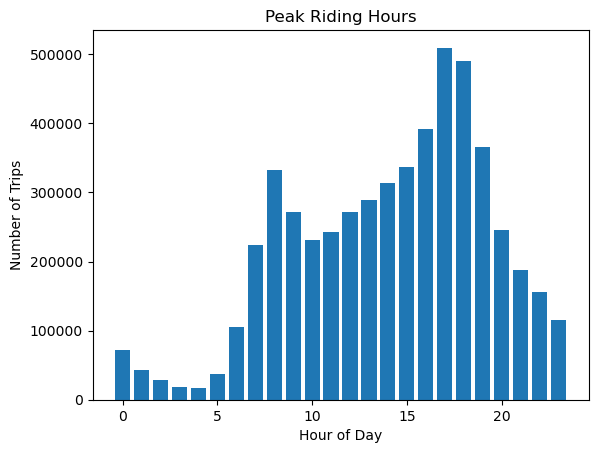

In [19]:
peak_hours = df.groupBy("hour") \
               .agg(count("*").alias("trip_count")) \
               .orderBy("trip_count", ascending=False)

peak_hours.show()

# Plot
peak_pd = peak_hours.toPandas()
peak_pd.to_csv("peak_riding_hours_summary.csv", index=False)

plt.figure()
plt.bar(peak_pd["hour"], peak_pd["trip_count"])
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.title("Peak Riding Hours")
plt.show()

### Q2. Station with highest trips starts

26/03/11 17:32:34 WARN MemoryStore: Not enough space to cache rdd_98_3 in memory! (computed 2.6 MiB so far)
26/03/11 17:32:34 WARN MemoryStore: Not enough space to cache rdd_98_9 in memory! (computed 3.9 MiB so far)
26/03/11 17:32:34 WARN MemoryStore: Not enough space to cache rdd_98_15 in memory! (computed 3.8 MiB so far)
26/03/11 17:32:34 WARN MemoryStore: Not enough space to cache rdd_98_18 in memory! (computed 5.8 MiB so far)
26/03/11 17:32:34 WARN MemoryStore: Not enough space to cache rdd_98_17 in memory! (computed 8.4 MiB so far)
26/03/11 17:32:34 WARN MemoryStore: Not enough space to cache rdd_98_22 in memory! (computed 4.8 MiB so far)
26/03/11 17:32:34 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for computing block rdd_98_26 in memory.
26/03/11 17:32:34 WARN MemoryStore: Not enough space to cache rdd_98_25 in memory! (computed 1128.1 KiB so far)
26/03/11 17:32:34 WARN MemoryStore: Not enough space to cache rdd_98_26 in memory! (computed 504.0 B s

+--------------------+-----------+
|  start_station_name|trip_starts|
+--------------------+-----------+
|     W 21 St & 6 Ave|      19123|
|Clinton St & Gran...|      18952|
|West St & Chamber...|      18208|
|Lafayette St & E ...|      17247|
|Pier 61 at Chelse...|      17212|
|Central Park S & ...|      16443|
|     9 Ave & W 33 St|      15683|
|  Broadway & W 58 St|      15638|
|University Pl & E...|      15480|
|     W 42 St & 6 Ave|      15332|
+--------------------+-----------+
only showing top 10 rows


26/03/11 17:32:35 WARN MemoryStore: Not enough space to cache rdd_98_98 in memory! (computed 3.9 MiB so far)
26/03/11 17:32:35 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for computing block rdd_98_101 in memory.
26/03/11 17:32:35 WARN MemoryStore: Not enough space to cache rdd_98_101 in memory! (computed 504.0 B so far)
26/03/11 17:32:35 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for computing block rdd_98_151 in memory.
26/03/11 17:32:35 WARN MemoryStore: Not enough space to cache rdd_98_151 in memory! (computed 504.0 B so far)
26/03/11 17:32:35 WARN MemoryStore: Not enough space to cache rdd_98_160 in memory! (computed 5.9 MiB so far)
26/03/11 17:32:35 WARN MemoryStore: Not enough space to cache rdd_98_167 in memory! (computed 3.9 MiB so far)
26/03/11 17:32:35 WARN MemoryStore: Not enough space to cache rdd_98_176 in memory! (computed 2.9 MiB so far)
26/03/11 17:32:35 WARN MemoryStore: Not enough space to cache rdd_98_18

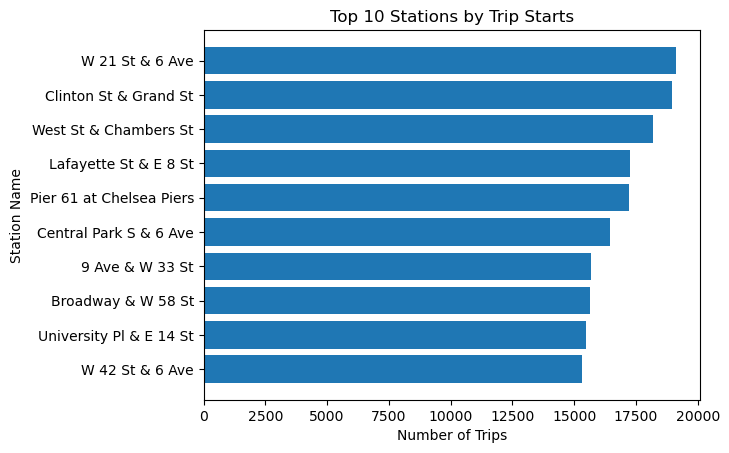

In [20]:
top_stations = df.groupBy("start_station_name") \
                 .agg(count("*").alias("trip_starts")) \
                 .orderBy("trip_starts", ascending=False)

top_stations.show(10)

# Plot
top_station_pd = top_stations.limit(10).toPandas()
top_station_pd.to_csv("top_station_summary.csv", index=False)

plt.figure()
plt.barh(top_station_pd["start_station_name"], top_station_pd["trip_starts"])
plt.xlabel("Number of Trips")
plt.ylabel("Station Name")
plt.title("Top 10 Stations by Trip Starts")
plt.gca().invert_yaxis()
plt.show()

### Q3. Average trip duration by user type

26/03/11 17:32:35 WARN MemoryStore: Not enough space to cache rdd_98_9 in memory! (computed 3.9 MiB so far)
26/03/11 17:32:35 WARN MemoryStore: Not enough space to cache rdd_98_1 in memory! (computed 2.9 MiB so far)
26/03/11 17:32:35 WARN MemoryStore: Not enough space to cache rdd_98_7 in memory! (computed 3.9 MiB so far)
26/03/11 17:32:35 WARN MemoryStore: Not enough space to cache rdd_98_11 in memory! (computed 3.4 MiB so far)
26/03/11 17:32:35 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for computing block rdd_98_16 in memory.
26/03/11 17:32:35 WARN MemoryStore: Not enough space to cache rdd_98_16 in memory! (computed 504.0 B so far)
26/03/11 17:32:35 WARN MemoryStore: Not enough space to cache rdd_98_15 in memory! (computed 3.8 MiB so far)
26/03/11 17:32:35 WARN MemoryStore: Not enough space to cache rdd_98_18 in memory! (computed 5.8 MiB so far)
26/03/11 17:32:35 WARN MemoryStore: Not enough space to cache rdd_98_22 in memory! (computed 4.8 MiB so fa

+-------------+------------------+
|member_casual|  avg_duration_min|
+-------------+------------------+
|       casual|18.445001781628402|
|       member|11.817853661212318|
+-------------+------------------+



26/03/11 17:32:36 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for computing block rdd_98_10 in memory.
26/03/11 17:32:36 WARN MemoryStore: Not enough space to cache rdd_98_10 in memory! (computed 504.0 B so far)
26/03/11 17:32:36 WARN MemoryStore: Not enough space to cache rdd_98_5 in memory! (computed 1111.4 KiB so far)
26/03/11 17:32:36 WARN MemoryStore: Not enough space to cache rdd_98_0 in memory! (computed 2.0 MiB so far)
26/03/11 17:32:36 WARN MemoryStore: Not enough space to cache rdd_98_1 in memory! (computed 1131.7 KiB so far)
26/03/11 17:32:36 WARN MemoryStore: Not enough space to cache rdd_98_3 in memory! (computed 1124.1 KiB so far)
26/03/11 17:32:36 WARN MemoryStore: Not enough space to cache rdd_98_16 in memory! (computed 4.1 MiB so far)
26/03/11 17:32:36 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for computing block rdd_98_20 in memory.
26/03/11 17:32:36 WARN MemoryStore: Failed to reserve initial memory thre

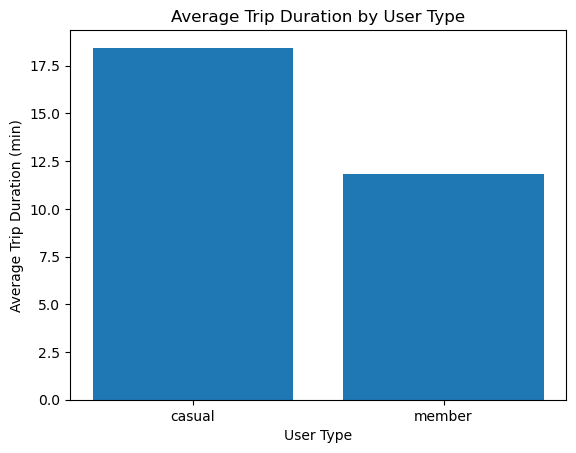

In [21]:
duration_by_user = df.groupBy("member_casual") \
                     .agg(avg("trip_duration_min").alias("avg_duration_min"))

duration_by_user.show()

# Plot
duration_pd = duration_by_user.toPandas()
duration_pd.to_csv("avd_duration_by_user_summary.csv", index=False)

plt.figure()
plt.bar(duration_pd["member_casual"], duration_pd["avg_duration_min"])
plt.xlabel("User Type")
plt.ylabel("Average Trip Duration (min)")
plt.title("Average Trip Duration by User Type")
plt.show()

### Q4. Weekday vs weekend demands

26/03/11 17:32:36 WARN MemoryStore: Not enough space to cache rdd_98_5 in memory! (computed 1111.4 KiB so far)
26/03/11 17:32:36 WARN MemoryStore: Not enough space to cache rdd_98_6 in memory! (computed 1125.1 KiB so far)
26/03/11 17:32:36 WARN MemoryStore: Not enough space to cache rdd_98_3 in memory! (computed 2.6 MiB so far)
26/03/11 17:32:36 WARN MemoryStore: Not enough space to cache rdd_98_1 in memory! (computed 2.9 MiB so far)
26/03/11 17:32:36 WARN MemoryStore: Not enough space to cache rdd_98_2 in memory! (computed 2.4 MiB so far)
26/03/11 17:32:36 WARN MemoryStore: Not enough space to cache rdd_98_18 in memory! (computed 5.8 MiB so far)
26/03/11 17:32:36 WARN MemoryStore: Not enough space to cache rdd_98_17 in memory! (computed 8.4 MiB so far)
26/03/11 17:32:36 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for computing block rdd_98_25 in memory.
26/03/11 17:32:36 WARN MemoryStore: Not enough space to cache rdd_98_25 in memory! (computed 504.0 B s

+--------+----------+
|day_type|trip_count|
+--------+----------+
| Weekday|   3971803|
| Weekend|   1323624|
+--------+----------+



26/03/11 17:32:37 WARN MemoryStore: Not enough space to cache rdd_98_58 in memory! (computed 3.9 MiB so far)
26/03/11 17:32:37 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for computing block rdd_98_62 in memory.
26/03/11 17:32:37 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for computing block rdd_98_61 in memory.
26/03/11 17:32:37 WARN MemoryStore: Not enough space to cache rdd_98_62 in memory! (computed 504.0 B so far)
26/03/11 17:32:37 WARN MemoryStore: Not enough space to cache rdd_98_61 in memory! (computed 504.0 B so far)
26/03/11 17:32:37 WARN MemoryStore: Not enough space to cache rdd_98_63 in memory! (computed 1129.3 KiB so far)
26/03/11 17:32:37 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for computing block rdd_98_70 in memory.
26/03/11 17:32:37 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for computing block rdd_98_69 in memory.
26/03/11 17:32:37 WARN Me

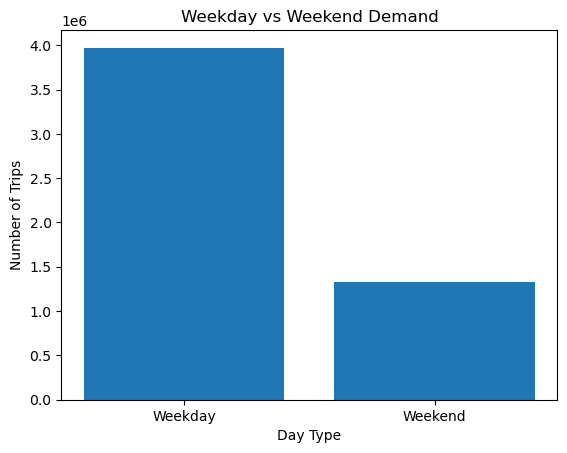

In [22]:
weekday_weekend = df.groupBy("day_type") \
                    .agg(count("*").alias("trip_count"))

weekday_weekend.show()

# Plot
weekday_pd = weekday_weekend.toPandas()
weekday_pd.to_csv("weekday_weekend_demand_summary.csv", index=False)

plt.figure()
plt.bar(weekday_pd["day_type"], weekday_pd["trip_count"])
plt.xlabel("Day Type")
plt.ylabel("Number of Trips")
plt.title("Weekday vs Weekend Demand")
plt.show()

### Q5. Average duration by day and hour

26/03/11 17:32:37 WARN MemoryStore: Not enough space to cache rdd_98_22 in memory! (computed 4.8 MiB so far)
26/03/11 17:32:37 WARN MemoryStore: Not enough space to cache rdd_98_24 in memory! (computed 3.1 MiB so far)
26/03/11 17:32:37 WARN MemoryStore: Not enough space to cache rdd_98_34 in memory! (computed 1131.9 KiB so far)
26/03/11 17:32:37 WARN MemoryStore: Not enough space to cache rdd_98_35 in memory! (computed 2.3 MiB so far)
26/03/11 17:32:37 WARN MemoryStore: Not enough space to cache rdd_98_41 in memory! (computed 3.5 MiB so far)
26/03/11 17:32:37 WARN MemoryStore: Not enough space to cache rdd_98_50 in memory! (computed 3.6 MiB so far)
26/03/11 17:32:37 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for computing block rdd_98_52 in memory.
26/03/11 17:32:37 WARN MemoryStore: Not enough space to cache rdd_98_52 in memory! (computed 504.0 B so far)
26/03/11 17:32:37 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for com

+--------+----+------------------+
|day_name|hour|      avg_duration|
+--------+----+------------------+
|  Friday|   0| 13.39617499498294|
|  Friday|   1|13.006632653061223|
|  Friday|   2|13.592324418351824|
|  Friday|   3|13.767753454432542|
|  Friday|   4|11.342704517704506|
|  Friday|   5|10.402058742033805|
|  Friday|   6|10.251821948692958|
|  Friday|   7|10.799011517018775|
|  Friday|   8|11.155889685361105|
|  Friday|   9|11.546964452027138|
|  Friday|  10|12.504724197206881|
|  Friday|  11|13.030692906315476|
|  Friday|  12|13.099936588736414|
|  Friday|  13|12.936599041572396|
|  Friday|  14|13.429158077077256|
|  Friday|  15| 13.78972366313829|
|  Friday|  16|13.615446557668777|
|  Friday|  17|13.613291358257714|
|  Friday|  18|13.972537685038562|
|  Friday|  19|13.634221737510668|
+--------+----+------------------+
only showing top 20 rows


26/03/11 17:32:39 WARN MemoryStore: Not enough space to cache rdd_98_24 in memory! (computed 3.1 MiB so far)
26/03/11 17:32:39 WARN MemoryStore: Not enough space to cache rdd_98_29 in memory! (computed 7.6 MiB so far)
26/03/11 17:32:39 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for computing block rdd_98_39 in memory.
26/03/11 17:32:39 WARN MemoryStore: Not enough space to cache rdd_98_39 in memory! (computed 504.0 B so far)
26/03/11 17:32:40 WARN MemoryStore: Not enough space to cache rdd_98_49 in memory! (computed 3.5 MiB so far)
26/03/11 17:32:40 WARN MemoryStore: Not enough space to cache rdd_98_50 in memory! (computed 1120.1 KiB so far)
26/03/11 17:32:40 WARN MemoryStore: Not enough space to cache rdd_98_52 in memory! (computed 3.2 MiB so far)
26/03/11 17:32:40 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for computing block rdd_98_62 in memory.
26/03/11 17:32:40 WARN MemoryStore: Not enough space to cache rdd_98_62 in 

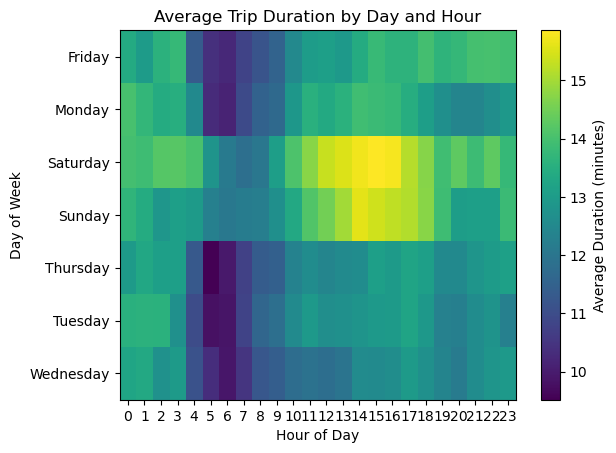

In [23]:
duration_variation = df.groupBy("day_name", "hour") \
                       .agg(avg("trip_duration_min").alias("avg_duration")) \
                       .orderBy("day_name", "hour")

duration_variation.show()

# Plot
duration_var_pd = duration_variation.toPandas()
duration_var_pd.to_csv("avg_duration_by_day&hour.csv", index=False)

pivot_table = duration_var_pd.pivot(
    index="day_name",
    columns="hour",
    values="avg_duration"
)

plt.figure()
plt.imshow(pivot_table, aspect="auto")
plt.colorbar(label="Average Duration (minutes)")
plt.yticks(range(len(pivot_table.index)), pivot_table.index)
plt.xticks(range(24), range(24))
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.title("Average Trip Duration by Day and Hour")
plt.show()

## **Performance Awareness**

In [24]:
df.write.mode("overwrite") \
  .partitionBy("day_name") \
  .parquet("citibike_cleaned_parquet")

26/03/11 17:32:42 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/03/11 17:32:42 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/03/11 17:32:42 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/03/11 17:32:42 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 69.09% for 11 writers
26/03/11 17:32:42 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 63.33% for 12 writers
26/03/11 17:32:42 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 69.09% for 11 writers
26/03/11 17:32:42 WARN MemoryManager: Total allocation exceeds 95.

26/03/11 18:51:40 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 144493 ms exceeds timeout 120000 ms
26/03/11 18:51:40 WARN SparkContext: Killing executors is not supported by current scheduler.
26/03/11 18:51:41 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:81)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:674)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1363)
	at o

The dataset is partitioned by **day_name**.  
Partitioning allows Spark to read only the relevant partitions during queries, reducing I/O and improving performance for time-based analyses.  
Using Parquet format improves performance because it stores data in a columnar layout, allowing Spark to read only the required columns during queries.  
Partitioning the dataset by day reduces the amount of data scanned for time-based analyses.  
Caching the dataset in memory prevents repeated computation when multiple analyses are performed on the same dataframe, improving execution speed.